In [ ]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(future))
suppressMessages(library(parallel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(viridis))
suppressMessages(library(qs))
suppressMessages(library(harmony))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(ggrepel)) 
suppressMessages(library(tidyr))
suppressMessages(library(foreach))
suppressMessages(library(doParallel))
suppressMessages(library(tidygraph))
suppressMessages(library(anndata))
suppressMessages(library(randomForest))
suppressMessages(library(pheatmap))
suppressMessages(library(dbscan))
suppressMessages(library(scDblFinder))
suppressMessages(library(cowplot))
library(stringr)


# Python 环境
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")

# 资源设定
plan("multicore", workers = 64)
options(future.globals.maxSize = 100000 * 1024^5)


ERROR: Error in library(scrattch.hicat): 不存在叫‘scrattch.hicat’这个名称的程序包


In [21]:
seurat = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260728_VTA_SCTseurat_harmony_rf_clean.rds')

In [22]:
DA = subset(seurat, Class == "DA" & nFeature_RNA > 800)
DA

An object of class Seurat 
39743 features across 3461 samples within 2 assays 
Active assay: SCT (19386 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers w

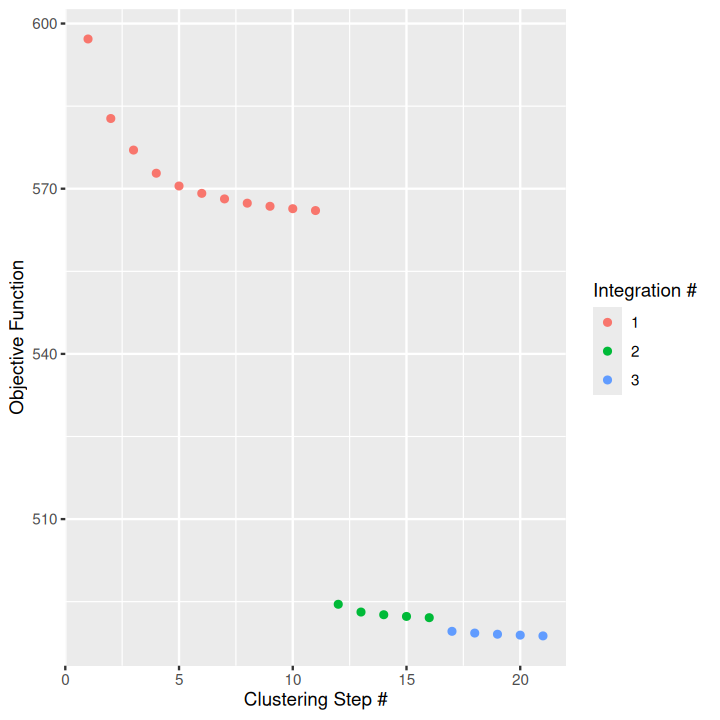

In [23]:
class_resolution = 0.3

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

sub = DA

assay = sub@assays$RNA$counts
meta = sub@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

sub = CreateSeuratObject(counts = new_assay)
sub = AddMetaData(sub, meta)

sub = NormalizeData(sub, normalization.method = "LogNormalize", scale.factor = 10000)
sub = FindVariableFeatures(sub, selection.method = "vst", nfeatures = 3000)
sub = ScaleData(sub, features = rownames(sub))

sub = sub %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, umap.method = "umap-learn")

sub = RunHarmony(
    sub, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:25,
    theta = 2
)

sub = sub %>%
    FindNeighbors(reduction = "harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:25)

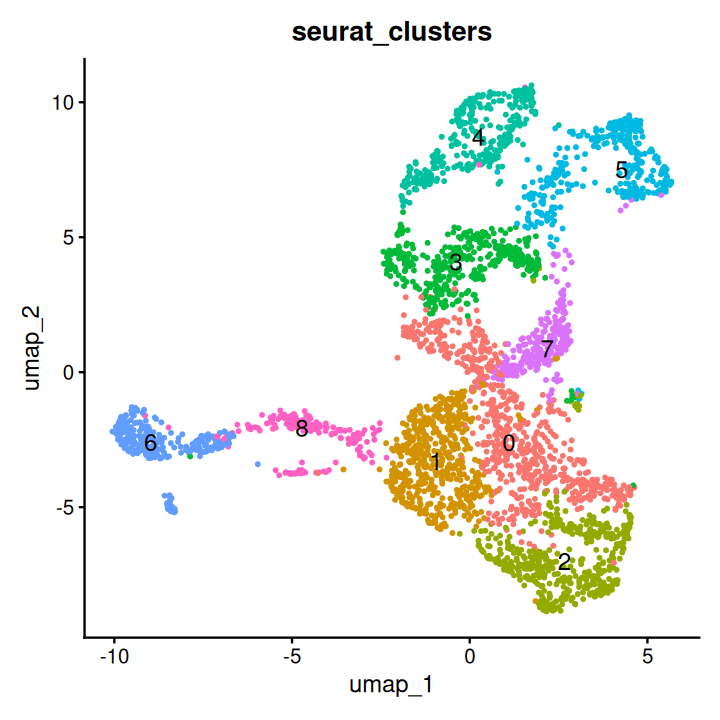

In [38]:
options(repr.plot.width=6, repr.plot.height=6)
DimPlot(sub, reduction = "umap", group.by = "seurat_clusters", label = TRUE, label.size = 5) + NoLegend()

In [87]:
sub

An object of class Seurat 
20344 features across 3461 samples within 1 assay 
Active assay: RNA (20344 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

In [24]:
sub_test = sub
df1 = read.table('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/IP-VTA_Mouse_anno.csv',sep = ',',header = 1,row.names = 1)
df2 = read.table('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/VTA_Mouse_anno.csv',sep = ',',header = 1,row.names = 1)

# 按照 index (细胞名/行名) 顺序添加
mouse_anno = c(df1$subclass_name, df2$subclass_name)
names(mouse_anno) = c(rownames(df1), rownames(df2))
# 只添加有 index 匹配的，用对象的 cell 名做索引
matched_anno = mouse_anno[colnames(sub_test)]
sub_test$Mouse_anno = matched_anno

In [106]:
stale_devices <- dev.list()
if (!is.null(stale_devices)) {
    stale_pdf_devices <- unname(stale_devices[names(stale_devices) == "pdf"])
    for (device_id in sort(stale_pdf_devices, decreasing = TRUE)) {
        dev.off(which = device_id)
    }
}

sub2 <- subset(sub_test, !(seurat_clusters %in% 8))
sub2$cluster <- paste0("DA_", sub2$seurat_clusters)
sub2$Mouse_anno <- as.character(sub2$Mouse_anno)
sub2$Mouse_anno[is.na(sub2$Mouse_anno)] <- "Unassigned"

anno_cluster_mat <- table(sub2$Mouse_anno, sub2$cluster)
valid_clusters <- apply(anno_cluster_mat, 2, function(x) sum(x) > 0 && sd(x) > 0)
anno_cluster_mat <- anno_cluster_mat[, valid_clusters, drop = FALSE]

if (nrow(anno_cluster_mat) < 2 || ncol(anno_cluster_mat) < 1) {
    stop("Heatmap requires at least two mouse annotations and one variable DA cluster.")
}

output_pdf <- "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_DA_cluster_mapping_mouse_whole_brain.pdf"
dir.create(dirname(output_pdf), recursive = TRUE, showWarnings = FALSE)

pheatmap(
    anno_cluster_mat,
    scale = "column",
    cluster_rows = FALSE,
    cluster_cols = FALSE,
    color = colorRampPalette(c("blue", "white", "red"))(100),
    border_color = NA,
    fontsize_row = 10,
    fontsize_col = 10,
    main = "Mapping to mouse whole-brain dataset",
    filename = output_pdf,
    width = 5,
    height = 6
)

In [25]:
table(sub_test$Mouse_anno, sub_test$seurat_clusters)

                                  
                                     0   1   2   3   4   5   6   7   8
  012 MEA Slc17a7 Glut               0   0   0   0   0   0   0   0   1
  030 L6 CT CTX Glut                 0   0   0   0   0   0   0   0   1
  043 OB-mi Frmd7 Gaba               0   0   0   0   0   0   1   0   0
  044 OB Dopa-Gaba                   0   0   0   0   0   0   0   0   1
  046 Vip Gaba                       0   0   0   0   0   0   0   0   1
  076 MEA-BST Lhx6 Nfib Gaba         0   0   0   0   0   0   1   0   0
  080 CEA-AAA-BST Six3 Sp9 Gaba      0   0   1   0   0   0   0   0   0
  086 MPO-ADP Lhx8 Gaba              0   0   0   0   0   0   0   0   1
  090 BST-MPN Six3 Nrgn Gaba         1   0   0   0   1   0   0   0   0
  102 DMH-LHA Gsx1 Gaba              0   0   0   0   0   0   0   0   1
  104 TU-ARH Otp Six6 Gaba           0   0   0   0   0   0   0   0   1
  114 COAa-PAA-MEA Barhl2 Glut       0   0   0   0   1   0   0   0   0
  132 AHN-RCH-LHA Otp Fezf1 Glut     0   0

In [71]:
pdf('/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_DA_cluster_UMAP.pdf', width = 6, height = 5)

options(repr.plot.width=6, repr.plot.height=5)
Idents(sub) <- 'cluster'
DimPlot(sub, reduction="umap", label=T,raster=FALSE)+coord_fixed()

dev.off()

agg_record_776832918 
                   2

In [ ]:
pdf('/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_DA_cluster_UMAP.pdf', width = 6, height = 5)

options(repr.plot.width=6, repr.plot.height=5)
Idents(sub) <- 'Animal'
DimPlot(sub, reduction="umap", label=T,raster=FALSE)+coord_fixed()

dev.off()


In [29]:
sub$cluster = paste0('DA_',sub$seurat_clusters)
sub$cluster %>% unique()

[1] "DA_3" "DA_0" "DA_8" "DA_2" "DA_7" "DA_4" "DA_6" "DA_5" "DA_1"

In [101]:
Idents(sub) <- 'cluster'
markers_da6 = FindMarkers(sub, only.pos = F,`ident.1` = 'DA_6', logfc.threshold = 0.25, test.use = "MAST")
markers_da6


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!



,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
KIF26B,0,-6.075090,0.041,0.981,0
UBB,0,7.576717,0.969,0.044,0
CACNA1A,0,-4.887004,0.069,0.985,0
DSCAM,0,-4.373269,0.072,0.983,0
ADARB2,0,-4.922149,0.093,0.989,0
FRMD4A,0,-4.155968,0.124,0.989,0
CSMD1,0,-4.984923,0.137,0.994,0
PRKG1,0,-5.003653,0.155,0.992,0
MAGI2,0,-4.047413,0.155,0.991,0


In [245]:
write.csv(
    markers_da6,
    "/mnt/90-connectome/Personal/CQW/midbrain/datasets/DA_6_markers.csv",
    row.names = TRUE
)

In [ ]:
markers_da6_1 <- markers_da6

markers_da6_1$gene <- rownames(markers_da6_1)

# 去除线粒体基因
MTGenes <- c(
  "ND6", "COX1", "ND5", "ND4", "ND2", "ND4L",
  "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1", "COX3"
)

markers_da6_1 <- markers_da6_1[
  !markers_da6_1$gene %in% MTGenes, 
]

# 去除 ENSMFAG 基因
markers_da6_1 <- markers_da6_1 %>%
  filter(!grepl("^ENSMFAG", gene))

# 去除 NA
markers_da6_1 <- markers_da6_1 %>%
  filter(!is.na(p_val_adj), !is.na(avg_log2FC))

# 定义显著性
markers_da6_1 <- markers_da6_1 %>%
  mutate(
    significance = case_when(
      p_val_adj < 0.01 & avg_log2FC > 0.5 ~ "DA_6_up",
      p_val_adj < 0.01 & avg_log2FC < -0.5 ~ "Other_up",
      TRUE ~ "NS"
    ),
    neg_log10_padj = -log10(p_val_adj)
  )

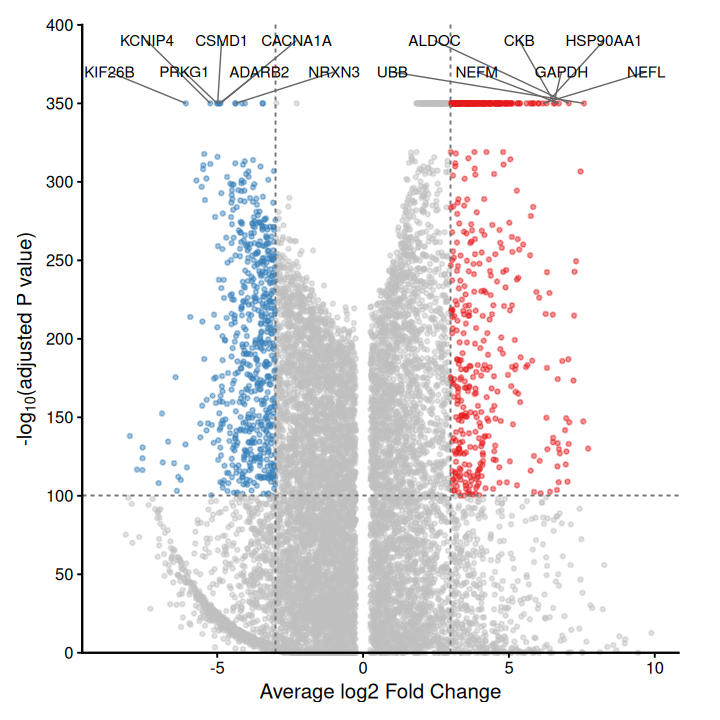

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

markers_da6_1$neg_log10_p_plot <- dplyr::case_when(
  is.na(markers_da6_1$p_val_adj) ~ NA_real_,
  markers_da6_1$p_val_adj == 0 ~ 350,
  TRUE ~ -log10(markers_da6_1$p_val_adj)
)

markers_da6_1$color_group <- dplyr::case_when(
  markers_da6_1$neg_log10_p_plot < 100 ~ "NS",
  abs(markers_da6_1$avg_log2FC) < 3 ~ "NS",

  markers_da6_1$p_val_adj < 0.01 &
    markers_da6_1$avg_log2FC >= 3 ~ "DA_6",

  markers_da6_1$p_val_adj < 0.01 &
    markers_da6_1$avg_log2FC <= -3 ~ "Other",

  TRUE ~ "NS"
)

up_pval_top5 <- markers_da6_1 %>%
  dplyr::filter(color_group == "DA_6") %>%
  dplyr::arrange(
    p_val_adj,
    dplyr::desc(avg_log2FC)
  ) %>%
  dplyr::slice_head(n = 7)

down_pval_top5 <- markers_da6_1 %>%
  dplyr::filter(color_group == "Other") %>%
  dplyr::arrange(
    p_val_adj,
    avg_log2FC
  ) %>%
  dplyr::slice_head(n = 7)

top_labels <- dplyr::bind_rows(
  up_pval_top5,
  down_pval_top5
) %>%
  dplyr::filter(!is.na(gene)) %>%
  dplyr::distinct(gene, .keep_all = TRUE)


x_min <- floor(min(markers_da6_1$avg_log2FC, na.rm = TRUE))
x_max <- ceiling(max(markers_da6_1$avg_log2FC, na.rm = TRUE))

n_left <- sum(top_labels$color_group == "Other")
n_right <- sum(top_labels$color_group == "DA_6")

left_label_x <- seq(
  x_min + 0.3,
  -1.0,
  length.out = n_left
)

right_label_x <- seq(
  1.0,
  x_max - 0.3,
  length.out = n_right
)

top_labels <- top_labels %>%
  dplyr::group_by(color_group) %>%
  dplyr::mutate(
    label_x = if (
      dplyr::first(color_group) == "Other"
    ) {
      left_label_x
    } else {
      right_label_x
    },

    label_y = rep(
      c(370, 390),
      length.out = dplyr::n()
    )
  ) %>%
  dplyr::ungroup()

p <- ggplot(
  markers_da6_1,
  aes(
    x = avg_log2FC,
    y = neg_log10_p_plot
  )
) +
  geom_point(
    aes(color = color_group),
    alpha = 0.45,
    size = 0.7
  ) +

  geom_vline(
    xintercept = c(-3, 3),
    linetype = "dashed",
    linewidth = 0.4,
    color = "grey45"
  ) +

  geom_hline(
    yintercept = -log10(1e-100),
    linetype = "dashed",
    linewidth = 0.4,
    color = "grey45"
  ) +

  # 连接原始点和标签
  geom_segment(
    data = top_labels,
    aes(
      x = avg_log2FC,
      y = neg_log10_p_plot,
      xend = label_x,
      yend = label_y
    ),
    inherit.aes = FALSE,
    color = "grey40",
    linewidth = 0.3
  ) +

  # 错位排列标签
  geom_text(
    data = top_labels,
    aes(
      x = label_x,
      y = label_y,
      label = gene
    ),
    inherit.aes = FALSE,
    size = 3.1,
    color = "black",
    hjust = 0.5,
    vjust = 0.5
  ) +

  scale_color_manual(
    values = c(
      "DA_6" = "#E41A1C",
      "Other" = "#377EB8",
      "NS" = "grey75"
    )
  ) +

  scale_y_continuous(
  limits = c(0, 400),
  breaks = seq(0, 400, by = 50),
  expand = c(0, 0)
) +

  labs(
    x = "Average log2 Fold Change",
    y = expression("-log"[10] * "(adjusted P value)")
  ) +

  coord_cartesian(clip = "off") +

  theme_classic(base_size = 12) +

  theme(
    legend.position = "none",
    axis.line = element_line(
      linewidth = 0.5,
      color = "black"
    ),
    axis.ticks = element_line(
      linewidth = 0.4,
      color = "black"
    ),
    plot.margin = ggplot2::margin(
      t = 15,
      r = 25,
      b = 10,
      l = 10
    )
  )

print(p)

In [200]:
ggplot2::ggsave(
  filename = "/mnt/90-connectome/Personal/CQW/midbrain/figure/volcano_DA6-1.pdf",
  plot = p,
  width = 6,
  height = 6,
  units = "in",
  device = grDevices::cairo_pdf
)


In [195]:
top_genes <- markers_da6_1 %>%
  filter(avg_log2FC > 1) %>%
  filter(p_val_adj < 1e-50) %>%
  slice_max(order_by = avg_log2FC, n = 100) %>%
  arrange(desc(avg_log2FC))

top_genes


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene,significance,neg_log10_padj,neg_log10_p_plot,color_group
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>
HSPB1,5.741672e-61,8.267433,0.192,0.003,1.168086e-56,HSPB1,DA_6_up,55.93253,55.93253,NS
RPS23,3.923336e-135,7.716482,0.430,0.004,7.981635e-131,RPS23,DA_6_up,130.09791,130.09791,DA_6
UBB,0.000000e+00,7.576717,0.969,0.044,0.000000e+00,UBB,DA_6_up,Inf,350.00000,DA_6
FAU,2.066180e-152,7.550076,0.485,0.005,4.203437e-148,FAU,DA_6_up,147.37640,147.37640,DA_6
HYPK,2.053298e-77,7.482799,0.268,0.004,4.177229e-73,HYPK,DA_6_up,72.37911,72.37911,NS
ACTB,1.267860e-311,7.457059,0.845,0.020,2.579335e-307,ACTB,DA_6_up,306.58849,306.58849,DA_6
SSR4,8.630123e-97,7.424478,0.323,0.003,1.755712e-92,SSR4,DA_6_up,91.75555,91.75555,NS
COX6A1,1.781825e-254,7.303270,0.756,0.011,3.624944e-250,COX6A1,DA_6_up,249.44070,249.44070,DA_6
ATPIF1,9.142855e-248,7.249501,0.722,0.021,1.860022e-243,ATPIF1,DA_6_up,242.73048,242.73048,DA_6


In [196]:
top_genes_list = top_genes$gene
length(top_genes_list)

[1] 100

In [197]:
top_genes$cluster = 'DA_6'
gene_list_up_1 <- split(top_genes$gene, top_genes$cluster)
gene_list_up_1

$DA_6
  [1] "HSPB1"    "RPS23"    "UBB"      "FAU"      "HYPK"     "ACTB"    
  [7] "SSR4"     "COX6A1"   "ATPIF1"   "FTH1"     "NDUFS5"   "RDH5"    
 [13] "SPP1"     "UBL5"     "ALDOC"    "DYNLL1"   "RPS15"    "RPS9"    
 [19] "RPL8"     "RPL18"    "PRDX1"    "RPS11"    "APOE"     "ATP5I"   
 [25] "RPL34"    "RPL41"    "ROMO1"    "NEFM"     "NDUFB7"   "C12orf57"
 [31] "S100B"    "MT2"      "CST3"     "RPL11"    "RPL30"    "CBR1"    
 [37] "RPS16"    "CKB"      "GAPDH"    "RPL18A"   "RPS3A"    "NDUFA1"  
 [43] "RPL24"    "ATP6V0B"  "NDUFB4"   "NEFH"     "RPL35"    "RPS7"    
 [49] "RPL27A"   "ELOB"     "CD63"     "HSP90AA1" "RPL23"    "RPL37"   
 [55] "RPL28"    "TPT1"     "POLR2L"   "MIEN1"    "PFN1"     "NEFL"    
 [61] "RPL27"    "RPL10"    "NOP10"    "RPL19"    "COX8A"    "CFL1"    
 [67] "SNCG"     "TCEAL4"   "RPS19"    "RPS26"    "Hsp90ab1" "RPS6"    
 [73] "DBNDD2"   "TSPYL4"   "RGS16"    "GLUL"     "PEBP1"    "SRP14"   
 [79] "MRPL55"   "HSPA8"    "PRDX5"    "SLC25A5"  "NDUFB10"  "GSTP1"   
 [85] "NDUFA4"   "TCEAL5"   "ACTG1"    "TUBA4A"   "RPS4X"    "B4GAT1"  
 [91] "FABP5"    "RGS4"     "SPCS1"    "ATP6V0C"  "ATP1B1"   "RAN"     
 [97] "TMSB10"   "TUFM"     "SAP18"    "THY1"

In [246]:
gene_list_up_1 = gene_list_up_1[sapply(gene_list_up_1, length) > 0]
lapply(names(gene_list_up_1), function(x){
  enrichr(gene_list_up_1[[x]], c("GO_Biological_Process_2025"))$GO_Biological_Process_2025 %>%
    mutate(seurat_clusters = x)
}) %>% bind_rows() -> GO_df_up1

Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2025... Done.
Parsing results... Done.


In [247]:
write.csv(
    GO_df_up1,
    "/mnt/90-connectome/Personal/CQW/midbrain/datasets/DA_6_top100_go_term.csv",
    row.names = TRUE
)

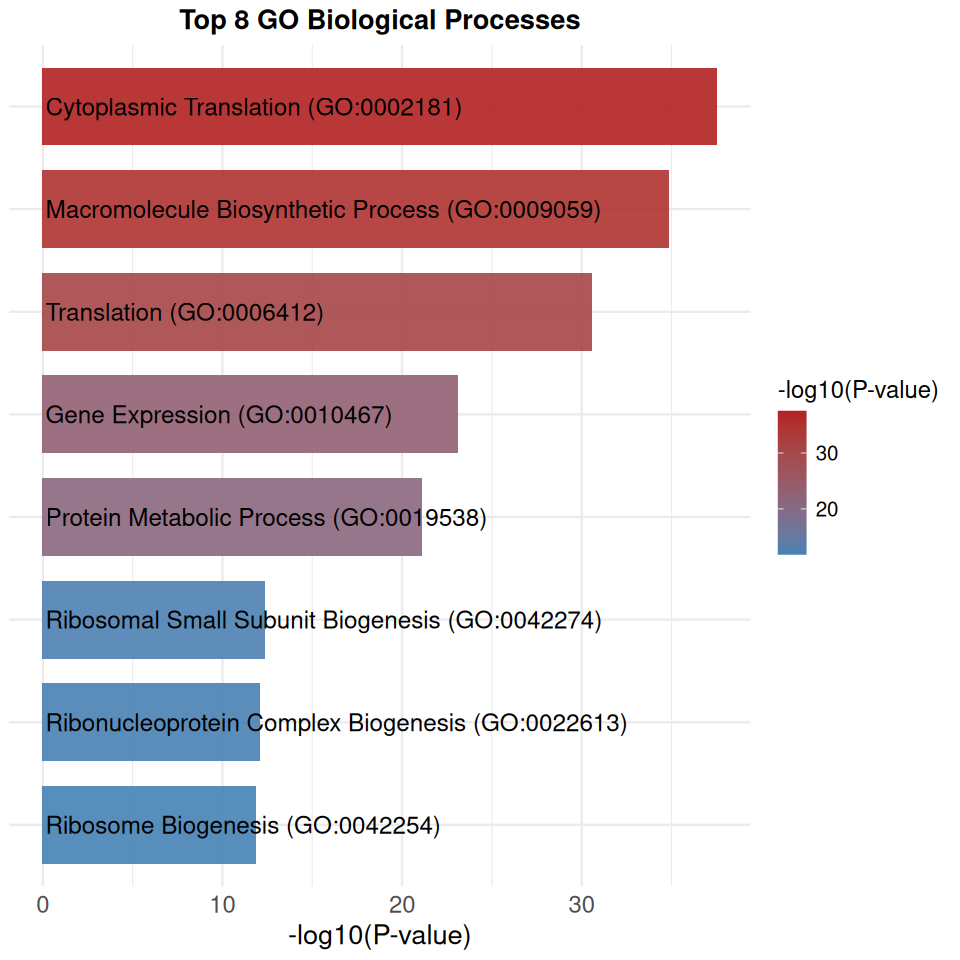

In [ ]:
# Get top 10 GO terms
top10_GO <- GO_df_up1 %>%
  slice_head(n = 8) %>%
  mutate(
    logP = -log10(P.value),
    GeneCount = as.numeric(sub("/.*", "", Overlap)),
    Term_label = Term
  )

options(repr.plot.width = 8, repr.plot.height = 8)

p2 <- ggplot(top10_GO, aes(x = logP, y = reorder(Term, logP), fill = logP)) +
  geom_col(width = 0.75, alpha = 0.9) +
  geom_text(
    aes(x = 0.15, label = Term_label),
    hjust = 0,
    color = "black",
    size = 5
  ) +
  scale_fill_gradient(
    low = "steelblue",
    high = "firebrick",
    name = "-log10(P-value)"
  ) +
  labs(
    title = "Top 8 GO Biological Processes",
    x = "-log10(P-value)",
    y = NULL
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.text.x = element_text(size = 14),
    axis.title.x = element_text(size = 16),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    plot.title = element_text(hjust = 0.5, size = 16, face = "bold")
  )

print(p2)

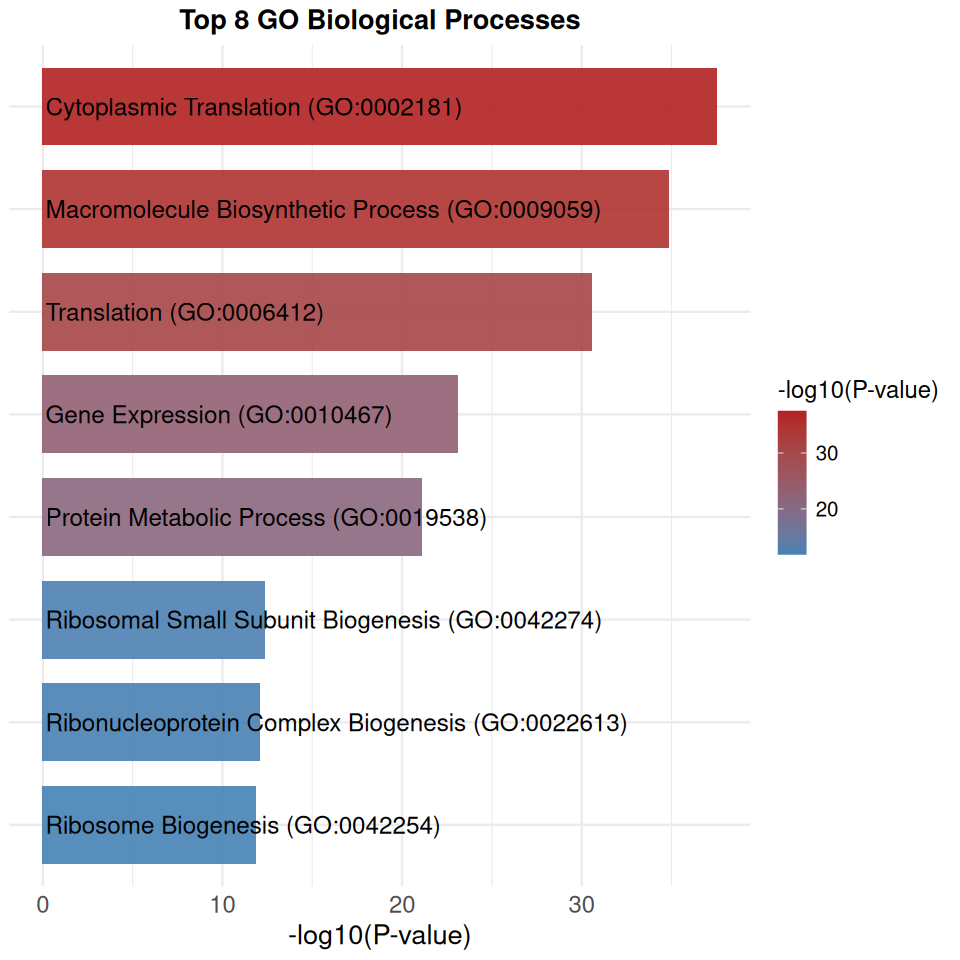

In [202]:
print(p2)

ggsave(
  filename = "/mnt/90-connectome/Personal/CQW/midbrain/figure/top10_GO_barplot-1.pdf",
  plot = p2,
  width = 8,
  height = 8,
  units = "in"
)

In [46]:
Idents(sub) <- 'cluster'
markers = FindAllMarkers(sub, only.pos = TRUE, logfc.threshold = 0.25, test.use = "MAST")
markers

Calculating cluster DA_3




Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster DA_0


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster DA_8


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster DA_2


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster DA_7


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Calculating cluster DA_4


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Cal

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
NXPH1,2.178336e-204,2.4735387,0.979,0.370,4.431607e-200,DA_3,NXPH1
IL1RAPL2,7.089372e-166,2.4932379,0.932,0.484,1.442262e-161,DA_3,IL1RAPL2
HTR4,1.737247e-151,2.2975294,0.911,0.385,3.534256e-147,DA_3,HTR4
BRINP3,3.416391e-146,3.0521454,0.801,0.250,6.950306e-142,DA_3,BRINP3
IQGAP2,2.300975e-136,2.1123668,0.913,0.587,4.681104e-132,DA_3,IQGAP2
PRKCQ,9.670723e-132,1.8648601,0.913,0.500,1.967412e-127,DA_3,PRKCQ
ANTXR2,6.534058e-128,2.9221288,0.719,0.167,1.329289e-123,DA_3,ANTXR2
ANGPT1,3.482259e-127,2.2205878,0.871,0.438,7.084308e-123,DA_3,ANGPT1
CDH13,9.330337e-124,1.3732091,0.997,0.824,1.898164e-119,DA_3,CDH13


In [244]:
write.csv(
    markers,
    "/mnt/90-connectome/Personal/CQW/midbrain/datasets/DA_cluster_markers.csv",
    row.names = TRUE
)

In [49]:
markers_filt = markers
MTGenes <- c("ND6","COX1","ND5","ND4","ND2","ND4L","ATP8","CYTB","COX2","ND3","ATP6","ND1","COX3")
markers_filt <- markers_filt[!markers_filt$gene %in% MTGenes, ]
markers_filt = markers_filt %>% filter(!grepl("^ENSMFAG", gene))


markers_filt = subset(markers_filt, p_val_adj < 0.01)
markers_filt = subset(markers_filt, avg_log2FC > 0.5)

table(markers_filt$cluster)


DA_3 DA_0 DA_8 DA_2 DA_7 DA_4 DA_6 DA_5 DA_1 
 400  230 1844  316  436  984 3919  781  725 

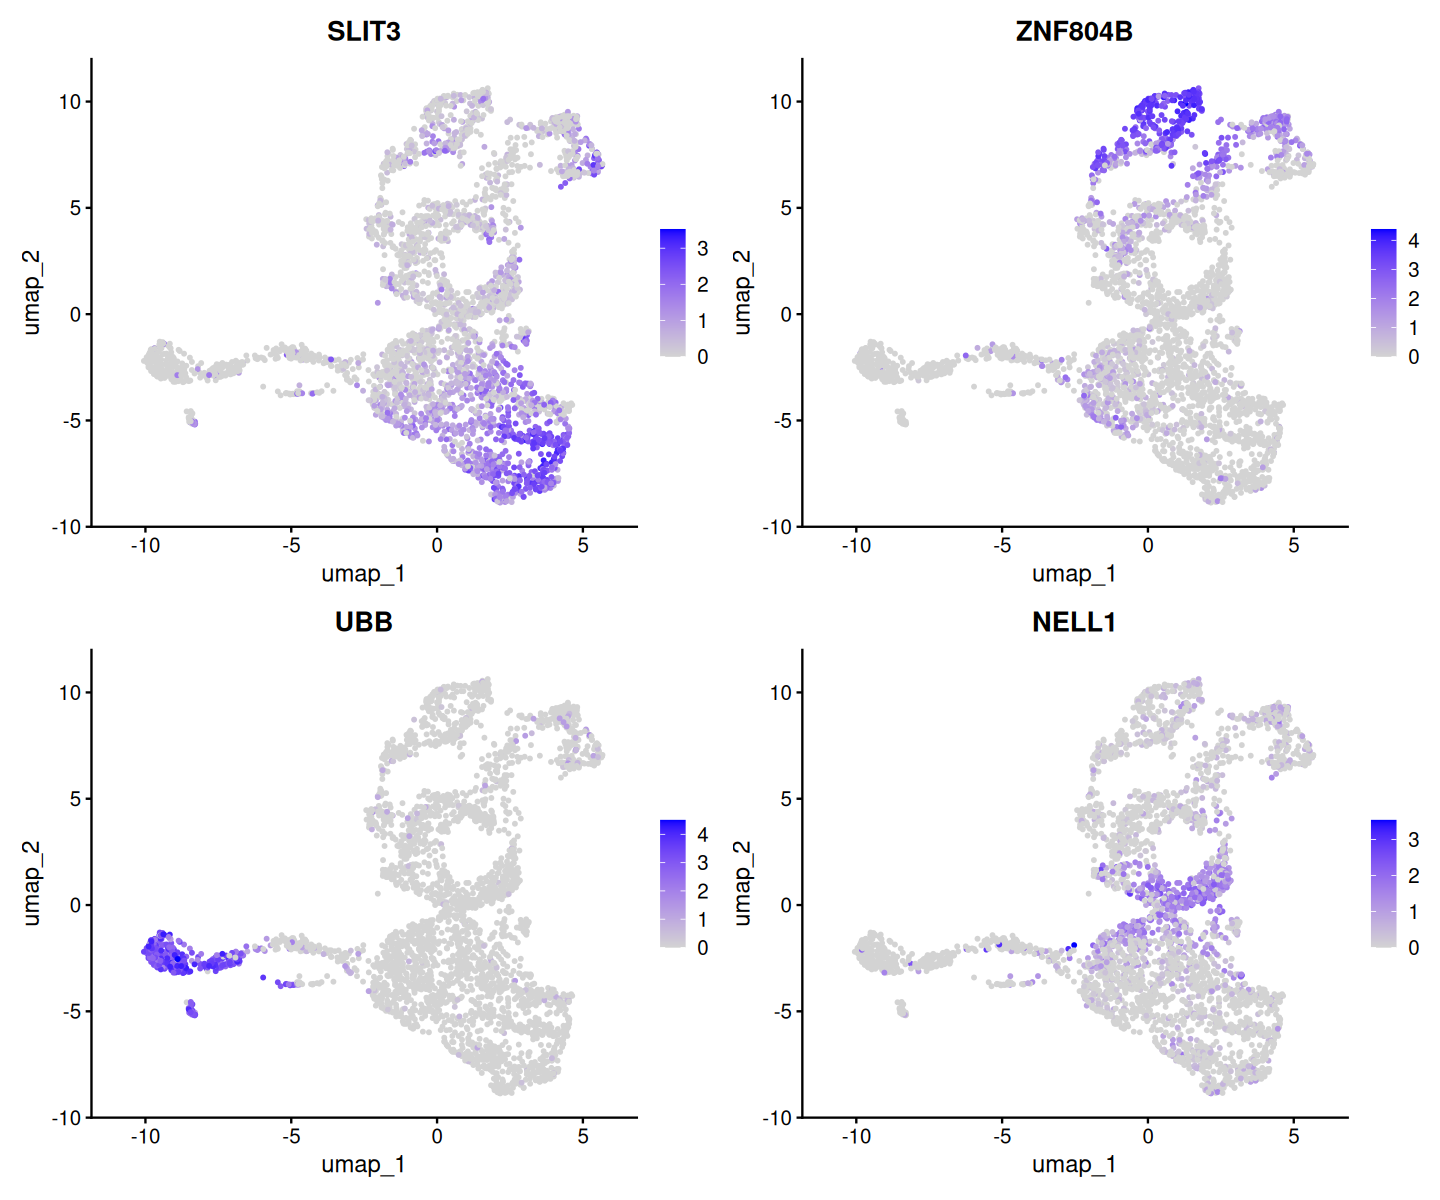

In [64]:
options(repr.plot.width=12, repr.plot.height=10)
FeaturePlot(sub, features = c("SLIT3","ZNF804B","UBB","NELL1"), ncol = 2, raster = FALSE)


In [77]:
pdf('/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_DA_cluster_top_markers.pdf', width = 12, height = 10)
options(repr.plot.width=12, repr.plot.height=10)
FeaturePlot(sub, features = c("SLIT3","ZNF804B","UBB","NELL1"), ncol = 2, raster = FALSE)
dev.off()

agg_record_1780995284 
                    2

In [ ]:
pdf("/mnt/90-connectome/Personal/CQW/midbrain/figure/DA_top_markers_dotplot.pdf",
    width = 6, height = 8)

DotPlot(sub, features = unique(markers_filt_top10$gene), dot.scale = 6, group.by = "cluster") +
    coord_flip() + RotatedAxis(45) +
    theme(axis.text.y = element_text(size = 12), axis.text.x = element_text(size = 12)) +
    scale_color_gradient2(
        low = "blue", mid = "white", high = "red",
        midpoint = 0, limits = c(-2.5, 2.5)
    )

dev.off()


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


agg_record_312928385 
                   2

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


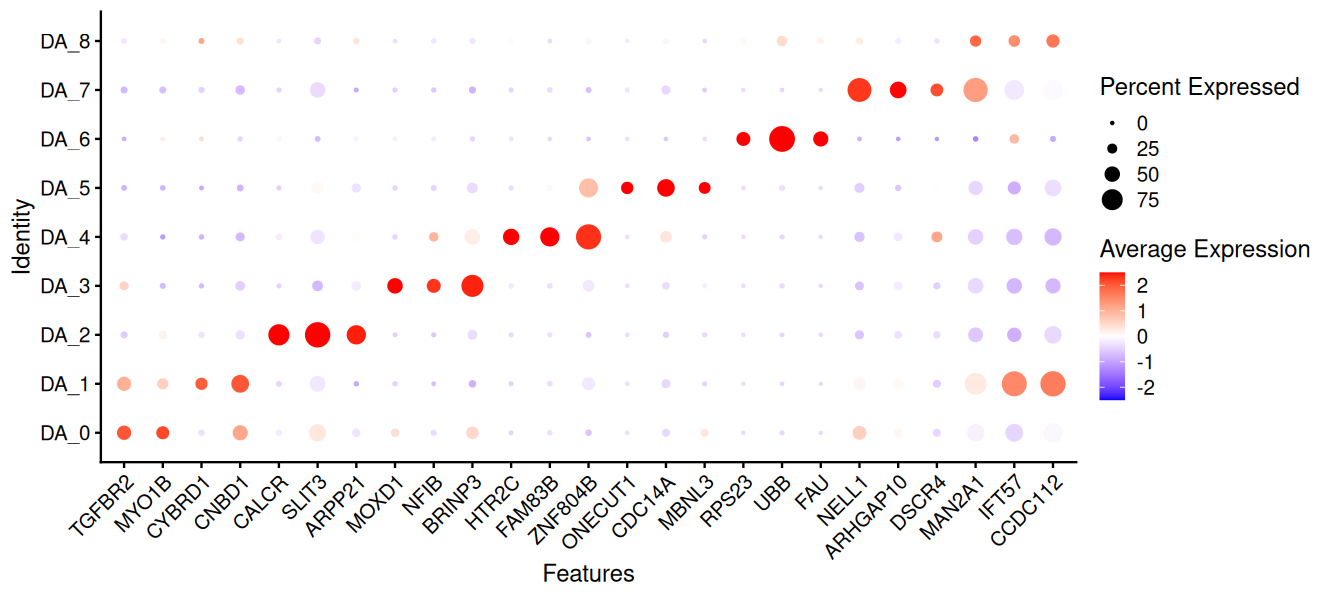

In [240]:
# 按 DA_0 到 DA_8 固定 cluster 顺序
cluster_order <- paste0("DA_", 0:8)
sub$cluster <- factor(as.character(sub$cluster), levels = cluster_order)

# 每个 cluster 选择 pct.1 > 0.3 且 avg_log2FC 最高的 3 个基因
markers_filt_top3 <- markers_filt %>%
    filter(cluster %in% cluster_order, pct.1 > 0.3) %>%
    mutate(cluster = factor(cluster, levels = cluster_order)) %>%
    group_by(cluster) %>%
    arrange(desc(avg_log2FC), .by_group = TRUE) %>%
    slice_head(n = 3) %>%
    ungroup()
delete_gene = c('CPED1','SOX6')
markers_filt_top3_sub = subset(markers_filt_top3, !gene %in% delete_gene)
# 基因顺序与 DA_0 -> DA_8 的 cluster 顺序一致
gene_order <- markers_filt_top3_sub %>%
    arrange(cluster, desc(avg_log2FC)) %>%
    pull(gene) %>%
    unique()

options(repr.plot.width = 11, repr.plot.height = 5)
DotPlot(sub, features = c(gene_order), dot.scale = 6, group.by = "cluster") +
    RotatedAxis(45) +
    theme(
        axis.text.y = element_text(size = 12),
        axis.text.x = element_text(size = 12)
    ) +
    scale_color_gradient2(
        low = "blue", mid = "white", high = "red",
        midpoint = 0, limits = c(-2.5, 2.5)
    )

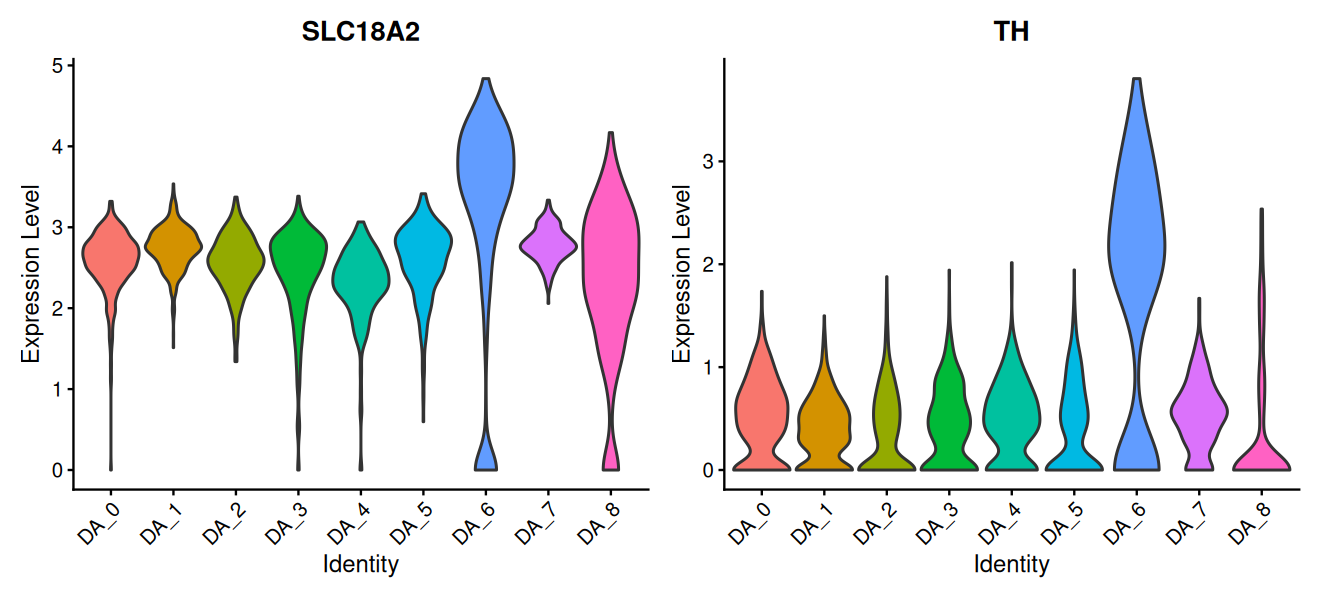

In [234]:
VlnPlot(sub, features = c('SLC18A2','TH'),pt.size = 0)

In [86]:
pdf("/mnt/90-connectome/Personal/CQW/midbrain/figure/DA_top_markers_dotplot-1.pdf", width = 11, height = 5)


# 按 DA_0 到 DA_8 固定 cluster 顺序
cluster_order <- paste0("DA_", 0:8)
sub$cluster <- factor(as.character(sub$cluster), levels = cluster_order)

# 每个 cluster 选择 pct.1 > 0.3 且 avg_log2FC 最高的 3 个基因
markers_filt_top3 <- markers_filt %>%
    filter(cluster %in% cluster_order, pct.1 > 0.3) %>%
    mutate(cluster = factor(cluster, levels = cluster_order)) %>%
    group_by(cluster) %>%
    arrange(desc(avg_log2FC), .by_group = TRUE) %>%
    slice_head(n = 3) %>%
    ungroup()

# 基因顺序与 DA_0 -> DA_8 的 cluster 顺序一致
gene_order <- markers_filt_top3 %>%
    arrange(cluster, desc(avg_log2FC)) %>%
    pull(gene) %>%
    unique()

options(repr.plot.width = 11, repr.plot.height = 5)
DotPlot(sub, features = gene_order, dot.scale = 6, group.by = "cluster") +
    RotatedAxis(45) +
    theme(
        axis.text.y = element_text(size = 12),
        axis.text.x = element_text(size = 12)
    ) +
    scale_color_gradient2(
        low = "blue", mid = "white", high = "red",
        midpoint = 0, limits = c(-2.5, 2.5)
    )

dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


agg_record_2010016283 
                    2

In [41]:
sampleRatio = 0.8
maxCell = 500
sampleDf = sub@meta.data[, c("cluster"), drop=F]
sampleList = split(sampleDf, sampleDf$cluster)
sampleList = lapply(sampleList, function(x) {
    sampleSize = as.integer(nrow(x)*0.8)
    if (sampleSize > maxCell) {
        sampleSize = maxCell
    }
    sampleIdx = 1:nrow(x)
    sampleIdx = sample(1:nrow(x), size=sampleSize, replace=F)
    return(x[sampleIdx,,drop=F])
})
sampleDf = Reduce(rbind, sampleList)
str(sampleDf)
table(sampleDf$cluster )

trainSeurat = sub[,rownames(sampleDf)]
table(trainSeurat$cluster)

'data.frame':	2719 obs. of  1 variable:
 $ cluster: chr  "DA_0" "DA_0" "DA_0" "DA_0" ...



DA_0 DA_1 DA_2 DA_3 DA_4 DA_5 DA_6 DA_7 DA_8 
 500  428  364  304  276  275  232  196  144 


DA_0 DA_1 DA_2 DA_3 DA_4 DA_5 DA_6 DA_7 DA_8 
 500  428  364  304  276  275  232  196  144 

In [42]:
Idents(trainSeurat) = "cluster"
classMarker = FindAllMarkers(trainSeurat)
classMarker = subset(classMarker, p_val_adj < 0.01 & avg_log2FC > 1.0)
table(classMarker$cluster)

Calculating cluster DA_0



Calculating cluster DA_8

Calculating cluster DA_7

Calculating cluster DA_4

Calculating cluster DA_3

Calculating cluster DA_6

Calculating cluster DA_1

Calculating cluster DA_5

Calculating cluster DA_2




DA_0 DA_8 DA_7 DA_4 DA_3 DA_6 DA_1 DA_5 DA_2 
  69   60  124  574  173 1268  197  158  111 

In [43]:
trainDf = as.data.frame(t(as.matrix(trainSeurat[["RNA"]]$data[unique(classMarker$gene), ])))
trainDf$cluster = trainSeurat$cluster
trainDf = subset(trainDf, cluster != "Uncertain")
trainDf$cluster = factor(trainDf$cluster)
# We need to modify the name of the columns
colnames(trainDf) = paste0("col_", colnames(trainDf))
colnames(trainDf) = gsub("-", "_", colnames(trainDf))
colnames(trainDf) = gsub(" ", "_", colnames(trainDf))

rf = randomForest(col_cluster~., data=trainDf, ntree=300)

 num [1:9, 1:10] 459 20 14 11 0 0 0 8 10 15 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:9] "DA_0" "DA_1" "DA_2" "DA_3" ...
  ..$ : chr [1:10] "DA_0" "DA_1" "DA_2" "DA_3" ...


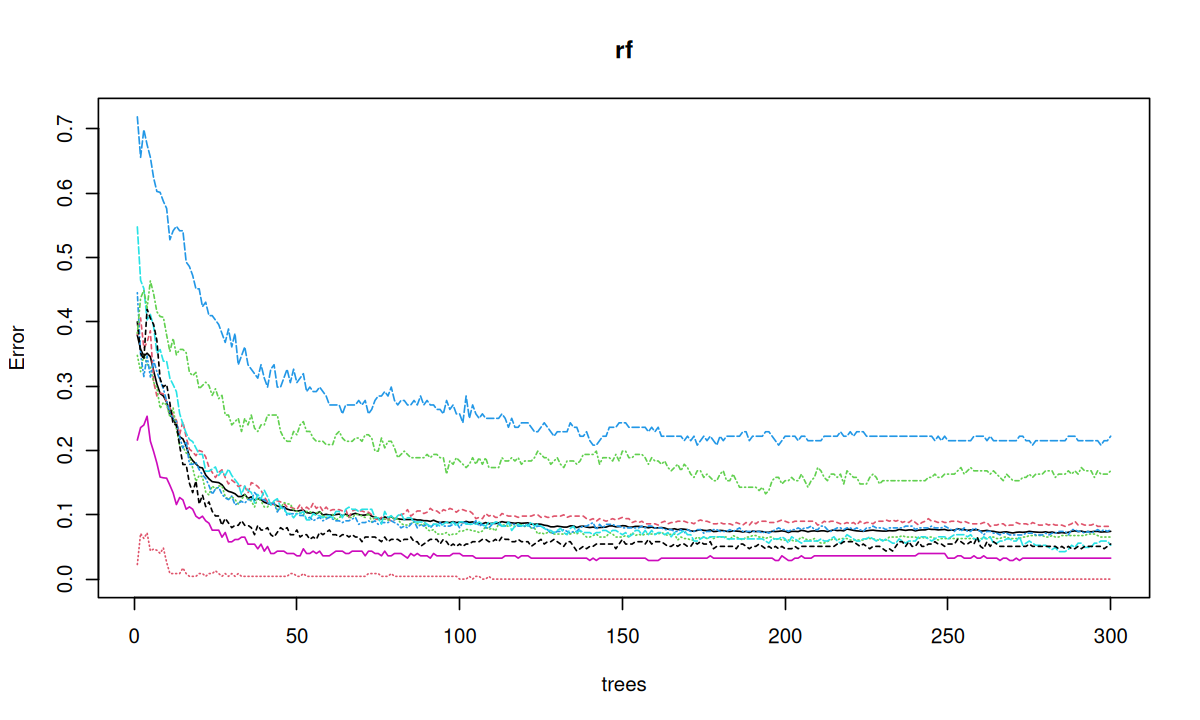

In [44]:
str(rf$confusion)
options(repr.plot.width=10, repr.plot.height=6)
plot(rf)


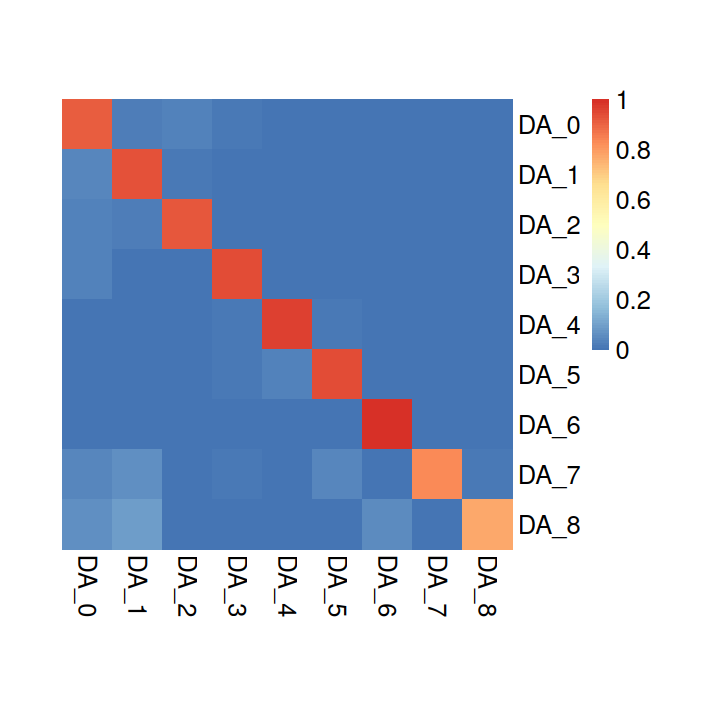

In [225]:
confusionRatio = t(apply(rf$confusion[1:9, 1:9], 1, function(x) {x/sum(x)}))
options(repr.plot.width=6, repr.plot.height=6)
pheatmap(confusionRatio, breaks=seq(0,1,0.01), cluster_rows=F, cluster_cols=F, border_color=NA, cellwidth=30, cellheight=30, fontsize=15,display_numbers =F)

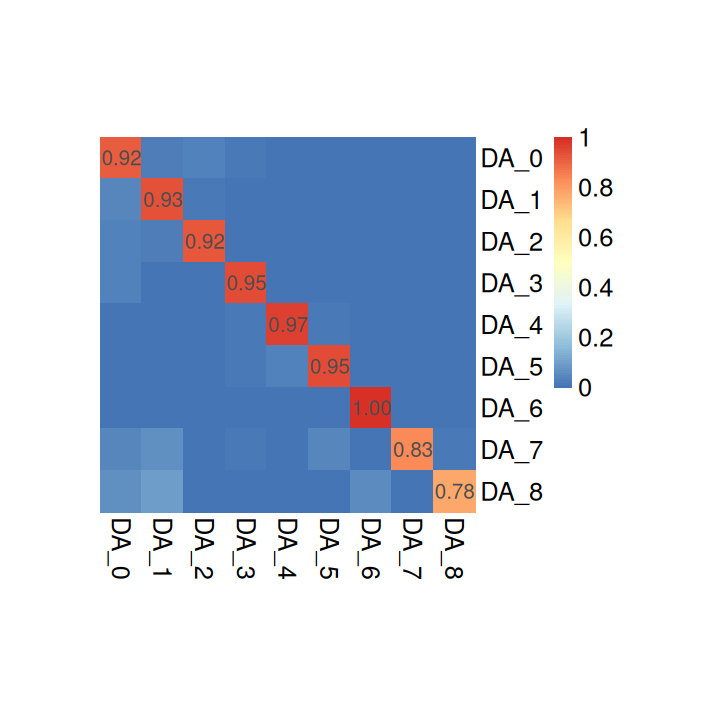

In [226]:
confusionRatio = t(apply(rf$confusion[1:9, 1:9], 1, function(x) {x/sum(x)}))

display_values <- ifelse(confusionRatio > 0.5, sprintf("%.2f", confusionRatio), "")

options(repr.plot.width = 6, repr.plot.height = 6)
pheatmap(
    confusionRatio,
    breaks = seq(0, 1, 0.01),
    cluster_rows = FALSE,
    cluster_cols = FALSE,
    border_color = NA,
    cellwidth = 25,
    cellheight = 25,
    fontsize = 15,
    display_numbers = display_values,
    # file = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_DA_randomForest_confusion-new-1.pdf"
)

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


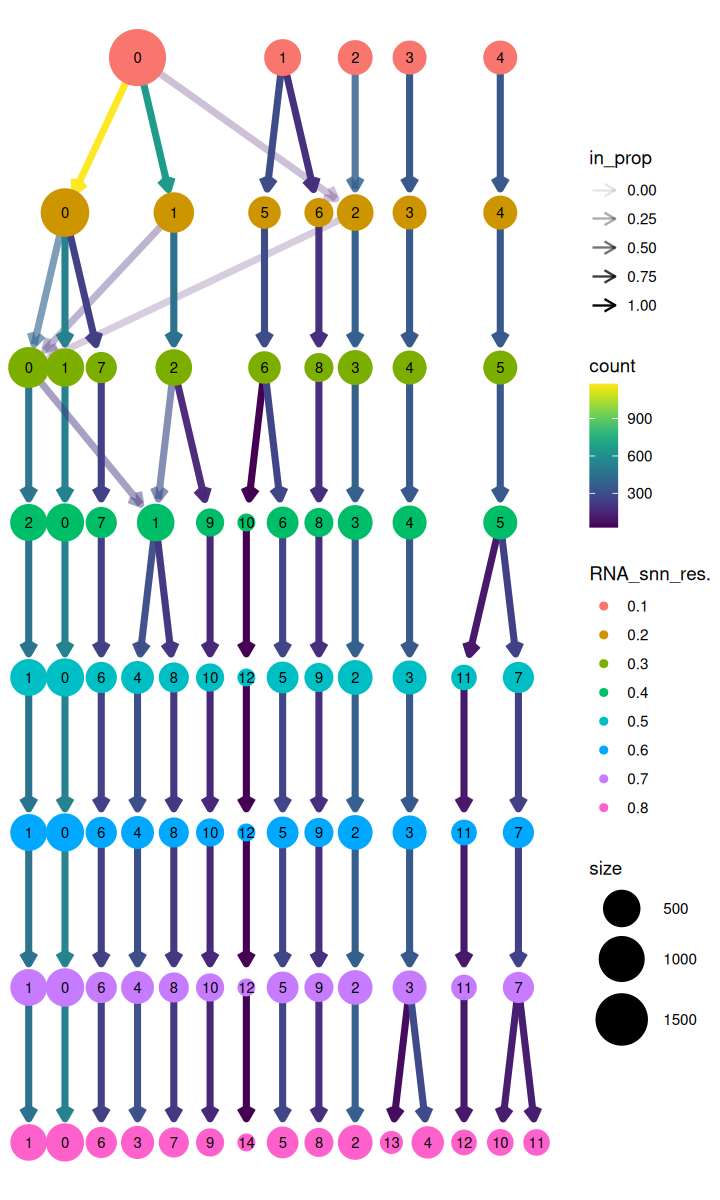

In [98]:
resolutions <- seq(0.1, 0.8, by = 0.1)

for (resolution in resolutions) {
    cluster_column <- sprintf("RNA_snn_res.%.1f", resolution)

    sub <- FindClusters(
        object = sub,
        graph.name = "RNA_snn",
        resolution = resolution,
        cluster.name = cluster_column,
        random.seed = 1234,
        verbose = FALSE
    )
}

options(repr.plot.width = 6, repr.plot.height = 10)

clustree::clustree(
    sub@meta.data,
    prefix = "RNA_snn_res.",
    layout = "sugiyama"
)

In [249]:
saveRDS(sub, '/mnt/90-connectome/Personal/CQW/midbrain/datasets/20260831_VTA_DA_cluster.rds')